# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

In [1]:
# Part 1: your work here
import numpy as np
import pandas as pd
import astropy 

from scipy import odr
from scipy.optimize import minimize
from sklearn.metrics import r2_score, root_mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = np.genfromtxt('../../labs/04/data/zahisr2.csv', delimiter=',', names = True)
df = pd.DataFrame(data)

In [3]:
x = df['logMstar']
xp = x - 9.5
y = df['logMBH']    
xerr = df['err_logMstar']
yerr = df['err_logMBH']

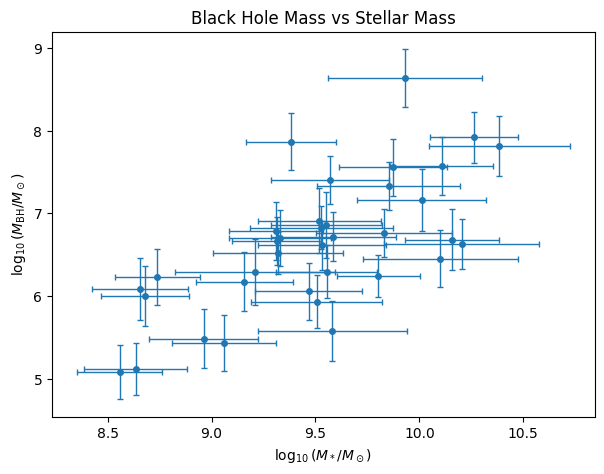

In [4]:
fig, ax = plt.subplots(figsize=(7,5))
ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', ms=4, elinewidth=1, capsize=2)
ax.set_xlabel(r"$\log_{10}(M_*/M_\odot)$")
ax.set_ylabel(r"$\log_{10}(M_{\rm BH}/M_\odot)$")
plt.title("Black Hole Mass vs Stellar Mass");

In [5]:
N = len(xp)
A = np.column_stack([xp, np.ones(N)])

ATA = A.T @ A
ATy = A.T @ y

theta_hat = np.linalg.solve(ATA, ATy)
alpha_hat, beta_hat = theta_hat

residual = y - A @ theta_hat
RSS = np.sum(residual**2)
s2 = RSS / (N - 2)
cov_theta = s2 * np.linalg.inv(ATA)

alpha_err = np.sqrt(cov_theta[0, 0])
beta_err = np.sqrt(cov_theta[1, 1])

print(f"alpha = {alpha_hat:.3f} ± {alpha_err:.3f}")
print(f"beta  = {beta_hat:.3f} ± {beta_err:.3f}")

alpha = 1.124 ± 0.206
beta  = 6.615 ± 0.099


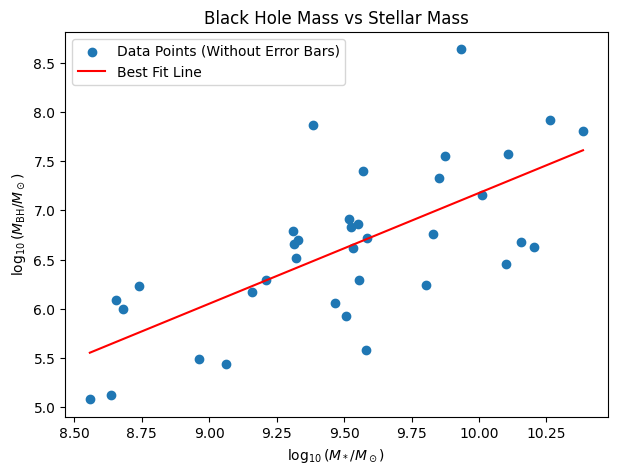

In [6]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(x, y, label='Data Points (Without Error Bars)')
ax.plot(x, alpha_hat * xp + beta_hat, color='red', label='Best Fit Line')
ax.set_xlabel(r"$\log_{10}(M_*/M_\odot)$")
ax.set_ylabel(r"$\log_{10}(M_{\rm BH}/M_\odot)$")
ax.legend()
ax.set_title("Black Hole Mass vs Stellar Mass");

**ANSWER (a few sentences):**

Here are some of the assumptions for ordinary least squares regression:
- Y and x are linearly related
- x measured without error and noise not related to x while the noise is from y
- No perfect multicollinearity
- Homoscedasticity
- Normal Distribution of Errors
- ++

The assumption we violate most directly is the assumption that the points of x have no uncertainty due to noise from astronomical observations as we know to expect but exclude from consideration here. 

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

In [7]:
# Part 2: your work here

y_arr = np.asarray(y) #got error about the type of y so I converted it to an array
yerr_arr = np.asarray(yerr)

w = 1.0 / yerr_arr**2                       

AtWA = A.T @ (A * w[:, None])            
AtWy = A.T @ (w * y_arr)                    
theta_wls = np.linalg.solve(AtWA, AtWy)
cov_wls = np.linalg.inv(AtWA)           
alpha_wls, beta_wls = theta_wls

chi2_red_wls = np.sum(w * (y_arr - A @ theta_wls)**2) / (N - 2)

print(f"alpha_wls = {alpha_wls:.3f} ± {np.sqrt(cov_wls[0,0]):.3f}")
print(f"beta_wls  = {beta_wls:.3f} ± {np.sqrt(cov_wls[1,1]):.3f}")
print(f"reduced chi^2 = {chi2_red_wls:.3f}")

alpha_wls = 1.121 ± 0.116
beta_wls  = 6.605 ± 0.054
reduced chi^2 = 3.220


In [8]:
def linear(p, xp):             
    return p[0] * xp + p[1]  

model  = odr.Model(linear)
data   = odr.RealData(xp, y, sx=xerr, sy=yerr)
fit    = odr.ODR(data, model, beta0=[alpha_hat, beta_hat]).run()   

alpha_odr, beta_odr = fit.beta
print(fit.sd_beta)                
print(np.sqrt(np.diag(fit.cov_beta)))  
print(fit.res_var)              

[0.24499937 0.11039115]
[0.21264955 0.09581505]
1.3273975235351034


In [9]:
def neg_loglike(theta, xp, y, sx, sy):
    alpha, beta, log_sint, mu_p, log_spop = theta
    log_sint = np.clip(log_sint, -10, 10)  
    log_spop = np.clip(log_spop, -10, 10)
    sint2 = np.exp(2 * log_sint)          
    spop2 = np.exp(2 * log_spop)        

    Cxx = spop2 + sx**2
    Cyy = alpha**2 * spop2 + sint2 + sy**2
    Cxy = alpha * spop2

    dx = xp - mu_p
    dy = y - (alpha * mu_p + beta)

    det  = Cxx * Cyy - Cxy**2
    quad = (Cyy * dx**2 - 2 * Cxy * dx * dy + Cxx * dy**2) / det

    return 0.5 * np.sum(quad + np.log(det) + 2 * np.log(2 * np.pi))

p0 = [alpha_hat, beta_hat, np.log(0.3), xp.mean(), np.log(xp.std())]
res = minimize(neg_loglike, p0, args=(xp, y, xerr, yerr), method="BFGS")

In [10]:
def num_hessian(f, p, h=1e-4):
    k = len(p)
    H = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            ei = np.zeros(k); ei[i] = h
            ej = np.zeros(k); ej[j] = h
            H[i, j] = (f(p + ei + ej) - f(p + ei - ej)
                       - f(p - ei + ej) + f(p - ei - ej)) / (4 * h * h)
    return H

f = lambda p: neg_loglike(p, xp, y, xerr, yerr)
H = num_hessian(f, res.x)
cov_ml = np.linalg.inv(H)
err = np.sqrt(np.diag(cov_ml))

alpha_ml, beta_ml, log_sint_ml, mu_ml, log_spop_ml = res.x
sint_ml = np.exp(log_sint_ml)
sint_ml_err = sint_ml * err[2]  

print(f"alpha_ml = {alpha_ml:.3f} ± {err[0]:.3f}")
print(f"beta_ml  = {beta_ml:.3f} ± {err[1]:.3f}")
print(f"sigma_int_ml = {sint_ml:.3f} ± {sint_ml_err:.3f}")

alpha_ml = 1.517 ± 0.279
beta_ml  = 6.653 ± 0.103
sigma_int_ml = 0.312 ± 0.136


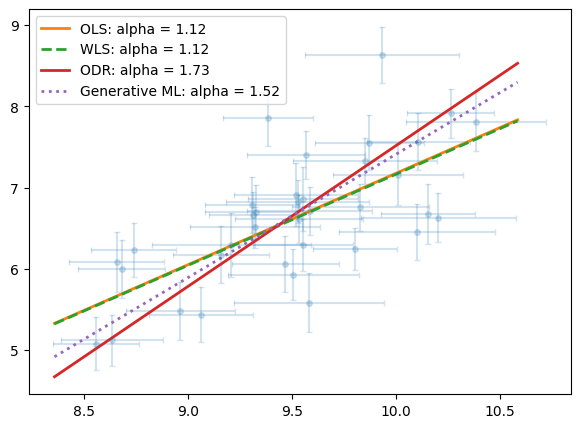

In [11]:
xg = np.linspace(x.min() - 0.2, x.max() + 0.2, 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', ms=4, alpha = 0.2, capsize=2)
for (a, b), lab, ls in [((alpha_hat, beta_hat), "OLS", "-"),
                        ((alpha_wls, beta_wls), "WLS", "--"),
                        ((alpha_odr, beta_odr), "ODR", "-"),
                        ((res.x[0], res.x[1]), "Generative ML", ":")]:
    ax.plot(xg, a * (xg - 9.5) + b, ls, lw=2, label=f"{lab}: alpha = {a:.2f}")
ax.legend();

In [12]:
summary = pd.DataFrame({
    "estimator":  ["OLS", "WLS", "ODR", "Generative ML"],
    "alpha":      [alpha_hat, alpha_wls, fit.beta[0], alpha_ml],
    "sigma_alpha":[alpha_err, np.sqrt(cov_wls[0,0]), fit.sd_beta[0], err[0]],
    "beta":       [beta_hat, beta_wls, fit.beta[1], beta_ml],
    "sigma_beta": [beta_err, np.sqrt(cov_wls[1,1]), fit.sd_beta[1], err[1]],
    "sigma_int":  [np.nan, np.nan, np.nan, sint_ml],
    "reduced_chi2": [s2, chi2_red_wls, fit.res_var, np.nan],
})
print(summary.round(3).to_string(index=False))

    estimator  alpha  sigma_alpha  beta  sigma_beta  sigma_int  reduced_chi2
          OLS  1.124        0.206 6.615       0.099        NaN         0.356
          WLS  1.121        0.116 6.605       0.054        NaN         3.220
          ODR  1.732        0.245 6.652       0.110        NaN         1.327
Generative ML  1.517        0.279 6.653       0.103      0.312           NaN


**FINAL ANSWER:** $\alpha = $ 1.517 $\pm$ 0.279 , $\beta = $ 6.653 $\pm$ 0.103 , $\sigma_{\rm int} = $ 0.312 $\pm$ 0.136 dex

The parameters and uncertainties chosen above are from the generative ML model. OLS and WLS both don't account for the error in x and intrinsic nosie, and the error bars are small showing a high confidence on an overfit estimate indicating regression dilution bias as demonstrated more in the week 6 lecture test. While ODR is a significant improvement as shown in the reduced chi-squared, it also does not factor in sigma_int, which the generative model does best (built accounting for sigma_y, sigma_x, and sigma_int).

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

- Closure: Pick simulate one dataset using the real catalog's $\sigma_x,\sigma_y$ values. Failure would be the fit models 2-3 sigma away from the known parameters
- Bias and efficiency: Simulate many dataasets (MC) and plot the estimates of alpha in each trial with the real alpha. Failure would be the ML centered (biased) not around the true alpha like the other models
- Coverage: Across the simulations, around 68% of the intervels contain the true alpha 68% of the time. Failure would be a signifacntly different percentage of intervals containing the truth 68% of the time.
- Sensitivity: Change x erros to 1.5x and 0.5x to see if the estimate changes. Failure is if the estimated alpha does not change as expected with such a drastic change in x errors.

In [ ]:
# Part 3b: execute the plan here

#simulate data
rng = np.random.default_rng(457)
truth = dict(alpha_t=1.5, beta_t=6.8, sint_t=0.3, mu_t=9.5, spop_t=0.5)

def simulate_and_fit(alpha_t, beta_t, sint_t, mu_t, spop_t, xerr, yerr, x_dist="normal", fit_sint=True):
    xerr = np.asarray(xerr)
    yerr = np.asarray(yerr)
    N = len(xerr)
    xt = (rng.uniform(mu_t - np.sqrt(3)*spop_t, mu_t + np.sqrt(3)*spop_t, N) if x_dist == "uniform"
          else rng.normal(mu_t, spop_t, N))
    xs = xt + rng.normal(0, xerr)
    ys = alpha_t*xt + beta_t + rng.normal(0, sint_t, N) + rng.normal(0, yerr)
    As = np.column_stack([xs, np.ones(N)])

    out = {"xs": xs, "ys": ys, "xerr": xerr, "yerr": yerr}
    out["OLS"] = np.linalg.solve(As.T @ As, As.T @ ys)[0]
    w = 1/yerr**2
    out["WLS"] = np.linalg.solve(As.T@(As*w[:,None]), As.T@(w*ys))[0]
    o = odr.ODR(odr.RealData(xs, ys, sx=xerr, sy=yerr), model, beta0=[alpha_t, beta_t]).run()
    out["ODR"] = o.beta[0]
    p0 = [alpha_t, beta_t, np.log(sint_t if fit_sint else 1e-3), mu_t-9.5, np.log(spop_t)]
    r = minimize(neg_loglike, p0, args=(xs, ys, xerr, yerr), method="BFGS")
    out["ML"] = r
    return out


In [15]:
# Closure
rec = simulate_and_fit(**truth, xerr=xerr, yerr=yerr)
H1 = num_hessian(lambda p: neg_loglike(p, rec["xs"], rec["ys"], rec["xerr"], rec["yerr"]), rec["ML"].x)
se1 = np.sqrt(np.diag(np.linalg.inv(H1)))

alpha_ml1, beta_ml1, logsint1 = rec["ML"].x[0], rec["ML"].x[1], rec["ML"].x[2]
print(f"alpha: truth {truth['alpha_t']}, fit {alpha_ml1:.3f} ± {se1[0]:.3f}  "
      f"({(alpha_ml1-truth['alpha_t'])/se1[0]:+.2f} sigma)")
print(f"beta:  truth {truth['beta_t']}, fit {beta_ml1:.3f} ± {se1[1]:.3f}  "
      f"({(beta_ml1-truth['beta_t'])/se1[1]:+.2f} sigma)")
print(f"sigma_int: truth {truth['sint_t']}, fit {np.exp(logsint1):.3f}")

alpha: truth 1.5, fit 1.275 ± 0.242  (-0.93 sigma)
beta:  truth 6.8, fit 9.068 ± 2.248  (+1.01 sigma)
sigma_int: truth 0.3, fit 0.249


estimator  mean_alpha   bias   std
      OLS       1.125 -0.375 0.172
      WLS       1.124 -0.376 0.172
      ODR       1.640  0.140 0.234
       ML       1.506  0.006 0.236


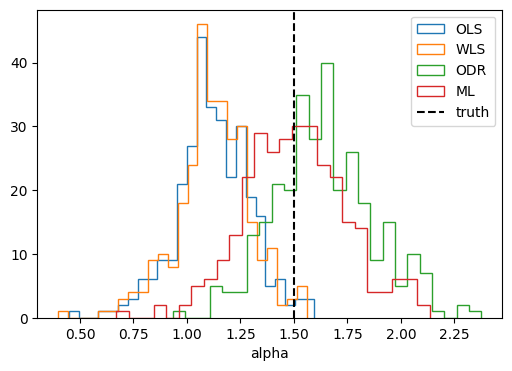

In [16]:
# Bias and effciency
n_sims = 300
recs = [simulate_and_fit(**truth, xerr=xerr, yerr=yerr) for _ in range(n_sims)]

ml_alpha = np.array([r["ML"].x[0] for r in recs])

summary = pd.DataFrame({
    "estimator": ["OLS","WLS","ODR","ML"],
    "mean_alpha": [np.mean([r[k] for r in recs]) for k in ["OLS","WLS","ODR"]] + [ml_alpha.mean()],
    "bias":       [np.mean([r[k] for r in recs])-truth["alpha_t"] for k in ["OLS","WLS","ODR"]]
                  + [ml_alpha.mean()-truth["alpha_t"]],
    "std":        [np.std([r[k] for r in recs]) for k in ["OLS","WLS","ODR"]] + [ml_alpha.std()],
})
print(summary.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(6,4))
for k in ["OLS","WLS","ODR"]:
    ax.hist([r[k] for r in recs], bins=25, histtype="step", label=k, lw=1.5)
ax.hist(ml_alpha, bins=25, histtype="step", label="ML", lw=1.5)
ax.axvline(truth["alpha_t"], color="k", ls="--", label="truth")
ax.set_xlabel("alpha"); ax.legend()

In [17]:
# Coverage
covered = {k: 0 for k in ["alpha","beta","sint"]}
n_singular = 0
for r in recs:
    try:
        H_i = num_hessian(lambda p: neg_loglike(p, r["xs"], r["ys"], r["xerr"], r["yerr"]), r["ML"].x)
        se = np.sqrt(np.diag(np.linalg.inv(H_i)))
    except np.linalg.LinAlgError:
        n_singular += 1
        continue
    covered["alpha"] += abs(r["ML"].x[0]-truth["alpha_t"]) < se[0]
    covered["beta"]  += abs(r["ML"].x[1]-truth["beta_t"])  < se[1]
    covered["sint"]  += abs(np.exp(r["ML"].x[2])-truth["sint_t"]) < se[2]*np.exp(r["ML"].x[2])

n_valid = n_sims - n_singular
print(f"skipped (singular Hessian): {n_singular}/{n_sims}")
print("68% coverage:", {k: f"{v/n_valid:.2f}" for k,v in covered.items()})

C:\Users\zahir\AppData\Local\Temp\ipykernel_39160\3935634469.py:7: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(np.diag(np.linalg.inv(H_i)))


skipped (singular Hessian): 4/300
68% coverage: {'alpha': '0.69', 'beta': '0.70', 'sint': '0.72'}


In [18]:
# Sensitivity
def simulate_correctly_fit_wrong(alpha_t, beta_t, sint_t, mu_t, spop_t, xerr, yerr, xerr_fit):
    xerr = np.asarray(xerr); yerr = np.asarray(yerr); xerr_fit = np.asarray(xerr_fit)
    N = len(xerr)
    xt = rng.normal(mu_t, spop_t, N)
    xs = xt + rng.normal(0, xerr)                       
    ys = alpha_t*xt + beta_t + rng.normal(0, sint_t, N) + rng.normal(0, yerr)
    p0 = [alpha_t, beta_t, np.log(sint_t), mu_t-9.5, np.log(spop_t)]
    r = minimize(neg_loglike, p0, args=(xs, ys, xerr_fit, yerr), method="BFGS") 
    return r.x[0]

a_over  = [simulate_correctly_fit_wrong(**truth, xerr=xerr, yerr=yerr, xerr_fit=1.5*xerr) for _ in range(100)]
a_under = [simulate_correctly_fit_wrong(**truth, xerr=xerr, yerr=yerr, xerr_fit=0.5*xerr) for _ in range(100)]
print(f"xerr told 1.5x too big: bias {np.mean(a_over)-truth['alpha_t']:+.3f}")
print(f"xerr told 0.5x too small: bias {np.mean(a_under)-truth['alpha_t']:+.3f}")

xerr told 1.5x too big: bias +0.361
xerr told 0.5x too small: bias -0.281


**WHAT THE CHECKS FOUND:**

All checks passed, with ML estimates around 1 sigma, the ML model not being too biased, around 68% of intervals containing 68% of the truth 68% of the time, and the alpha estimate changed significantly if xerr changed significantly.

.## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

I used Claude chats for past labs when generating a log likelyhood function while reusing and transforming it for this labs task. AI also proved useful to do simple code implementation tasks like printing summary tables and formatting plots much faster and conventionally after my own iterations. Claude was used for the monte carlo simulations as getting lost in bugs for thoe tasks take time, but it was necessary to ask for print statements for every cell and to output justifications of every cell block to help catch its own mistakes and for me to as well. All written responses were handtyped and intuition was further built from the 9/29 test for the weaknesses of OLS and WLS + regression dilution bias.